TIME SERIES

In [29]:
import sys
import os

# ----- Add project root so Python can find "src/" -----
PROJECT_ROOT = os.path.abspath("..")  # notebook folder → go up one level
sys.path.append(PROJECT_ROOT)

print("Project root added:", PROJECT_ROOT)


Project root added: C:\Users\DEREK ISOKPEHI\Desktop\FYP FYP\Multimodial Anomaly Detection System


In [30]:
import sys, os
PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

from src.detection_tabular import detect_tabular_anomalies
from src.detection_timeseries import detect_timeseries_anomalies
from src.detection_image import detect_image_anomaly
from src.anomaly_router import detect_anomaly

print("OK!")


NameError: name 'null' is not defined

In [1]:
import numpy as np #numerical operations
import pandas as pd #DataFrame handling
import matplotlib.pyplot as plt #plotting for visual inspection

plt.style.use("seaborn-v0_8")  # makes plots look cleaner


In [7]:
import aeon
aeon.__version__

'1.3.0'

In [2]:

##CREATE SYNTHETIC TIME SERIES DATA

# We simulate a smooth periodic signal (like sensors, heartbeat, CPU usage)
# Then we inject an anomaly burst between index 180–200.
# This helps us test how well different methods detect the anomaly.

rng = np.random.default_rng(42)

# Time axis (300 time steps)
time = np.arange(300)

# Base clean sinusoidal signal + small noise
normal_signal = np.sin(time * 0.1) + rng.normal(scale=0.05, size=300)

# Inject anomaly burst: sudden abnormal increase for 20 time steps
signal_with_anomaly = normal_signal.copy()
signal_with_anomaly[180:200] += 2.5  # spike added

# Put into a DataFrame
ts_df = pd.DataFrame({
    "time": time,
    "value": signal_with_anomaly
})

ts_df.head()


,time,value
0,0,0.015236
1,1,0.047834
2,2,0.236192
3,3,0.342548
4,4,0.291867


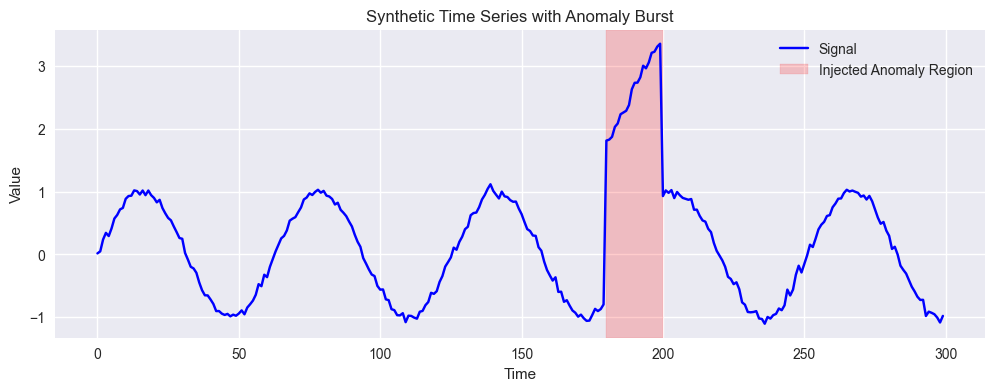

In [3]:
##VISUALIZE THE TIME SERIES AND THE ANOMALY BURST


plt.figure(figsize=(12,4))
plt.plot(ts_df["time"], ts_df["value"], label="Signal", color="blue")
plt.axvspan(180, 200, color='red', alpha=0.2, label="Injected Anomaly Region")

plt.title("Synthetic Time Series with Anomaly Burst")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()


In [4]:
## ROLLING Z-SCORE ANOMALY DETECTION


# A point is an anomaly if its Z-score > 3 (statistical threshold)
# Z = (value - rolling_mean) / rolling_std

window = 20  # size of rolling window

rolling_mean = ts_df["value"].rolling(window).mean()
rolling_std  = ts_df["value"].rolling(window).std()

z_scores = (ts_df["value"] - rolling_mean) / rolling_std

# Flag anomalies where |Z| > 3
ts_df["z_anomaly"] = (z_scores.abs() > 3).astype(int)

ts_df.head()


,time,value,z_anomaly
0,0,0.015236,0
1,1,0.047834,0
2,2,0.236192,0
3,3,0.342548,0
4,4,0.291867,0


In [5]:
## ISOLATION FOREST ANOMALY DETECTION (ML)

# Isolation Forest isolates observations by randomly selecting features
# and splitting values. Anomalies require fewer splits.

from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.02, random_state=42)

# IF returns -1 for anomaly, 1 for normal → convert to 1/0
ts_df["if_anomaly"] = (iso.fit_predict(ts_df[["value"]]) == -1).astype(int)

ts_df.head()


,time,value,z_anomaly,if_anomaly
0,0,0.015236,0,0
1,1,0.047834,0,0
2,2,0.236192,0,0
3,3,0.342548,0,0
4,4,0.291867,0,0


In [16]:
import aeon
aeon.__version__


'1.3.0'

In [12]:
## SLIDING WINDOW SEGMENTATION (NumPy version)

# We manually create sliding windows using numpy, because AEON 1.3+ 
# changed its internal windowing modules.

import numpy as np

def sliding_window_view(arr, window_size):
    """Return overlapping windows of size window_size for a 1D array."""
    shape = (arr.size - window_size + 1, window_size)
    strides = (arr.strides[0], arr.strides[0])
    return np.lib.stride_tricks.as_strided(arr, shape=shape, strides=strides)

# Extract windows of length 20
windows = sliding_window_view(ts_df["value"].values, 20)

windows.shape


(281, 20)

In [19]:
from aeon.utils.discovery import all_estimators
all_estimators(type_filter="anomaly-detector")


[('CBLOF', aeon.anomaly_detection.series.distance_based._cblof.CBLOF),
 ('COPOD', aeon.anomaly_detection.series.distribution_based._copod.COPOD),
 ('ClassificationAdapter',
  aeon.anomaly_detection.collection._classification.ClassificationAdapter),
 ('DWT_MLEAD',
  aeon.anomaly_detection.series.distribution_based._dwt_mlead.DWT_MLEAD),
 ('IsolationForest',
  aeon.anomaly_detection.series.outlier_detection._iforest.IsolationForest),
 ('KMeansAD', aeon.anomaly_detection.series.distance_based._kmeans.KMeansAD),
 ('LOF', aeon.anomaly_detection.series.distance_based._lof.LOF),
 ('LeftSTAMPi',
  aeon.anomaly_detection.series.distance_based._left_stampi.LeftSTAMPi),
 ('MERLIN', aeon.anomaly_detection.series.distance_based._merlin.MERLIN),
 ('OneClassSVM',
  aeon.anomaly_detection.series.outlier_detection._one_class_svm.OneClassSVM),
 ('OutlierDetectionAdapter',
  aeon.anomaly_detection.collection._outlier_detection.OutlierDetectionAdapter),
 ('PyODAdapter', aeon.anomaly_detection.series._pyod

In [24]:

# AEON ANOMALY DETECTOR: STRAY (1D Time-Series Mode)

# STRAY in AEON 1.3.0 expects raw time series, not windows.

from aeon.anomaly_detection.series.outlier_detection import STRAY

# Create model
aeon_model = STRAY()

# Fit + predict on 1D time series
aeon_preds = aeon_model.fit_predict(ts_df["value"].values)

# Add to dataframe
ts_df["aeon_anomaly"] = aeon_preds.astype(int)

ts_df.head()


,time,value,z_anomaly,if_anomaly,aeon_anomaly
0,0,0.015236,0,0,0
1,1,0.047834,0,0,0
2,2,0.236192,0,0,0
3,3,0.342548,0,0,0
4,4,0.291867,0,0,0


In [25]:
ts_df["aeon_anomaly"] = aeon_preds.astype(int)


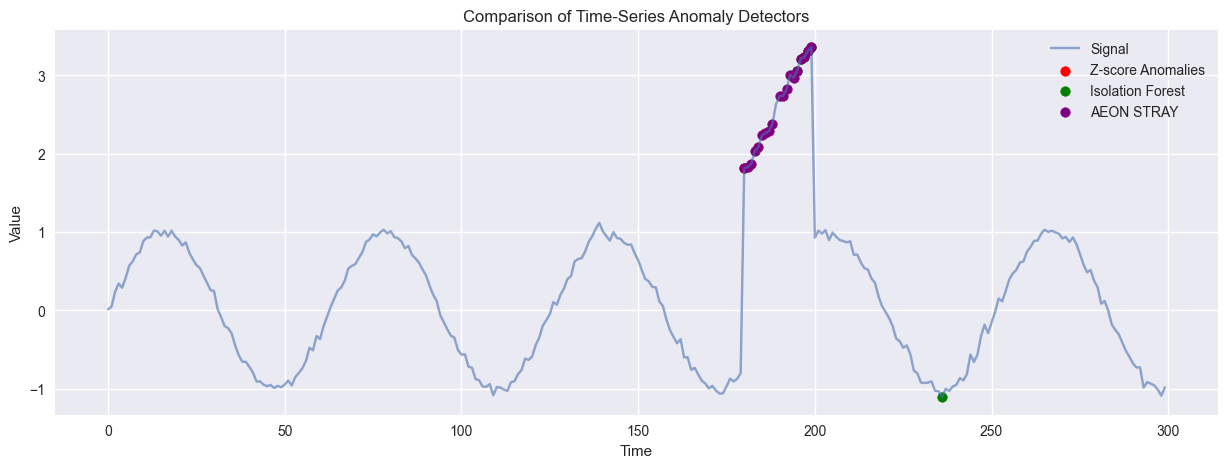

In [26]:
plt.figure(figsize=(15,5))
plt.plot(ts_df["time"], ts_df["value"], label="Signal", alpha=0.6)

# Z-score anomalies
plt.scatter(ts_df[ts_df["z_anomaly"] == 1]["time"],
            ts_df[ts_df["z_anomaly"] == 1]["value"],
            color="red", label="Z-score Anomalies")

# Isolation Forest anomalies
plt.scatter(ts_df[ts_df["if_anomaly"] == 1]["time"],
            ts_df[ts_df["if_anomaly"] == 1]["value"],
            color="green", label="Isolation Forest")

# STRAY (AEON) anomalies
plt.scatter(ts_df[ts_df["aeon_anomaly"] == 1]["time"],
            ts_df[ts_df["aeon_anomaly"] == 1]["value"],
            color="purple", label="AEON STRAY")

plt.title("Comparison of Time-Series Anomaly Detectors")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()


In [27]:
ts_df["ensemble_score"] = (
    ts_df["z_anomaly"] +
    ts_df["if_anomaly"] +
    ts_df["aeon_anomaly"]
)

ts_df["ensemble_anomaly"] = (ts_df["ensemble_score"] >= 2).astype(int)


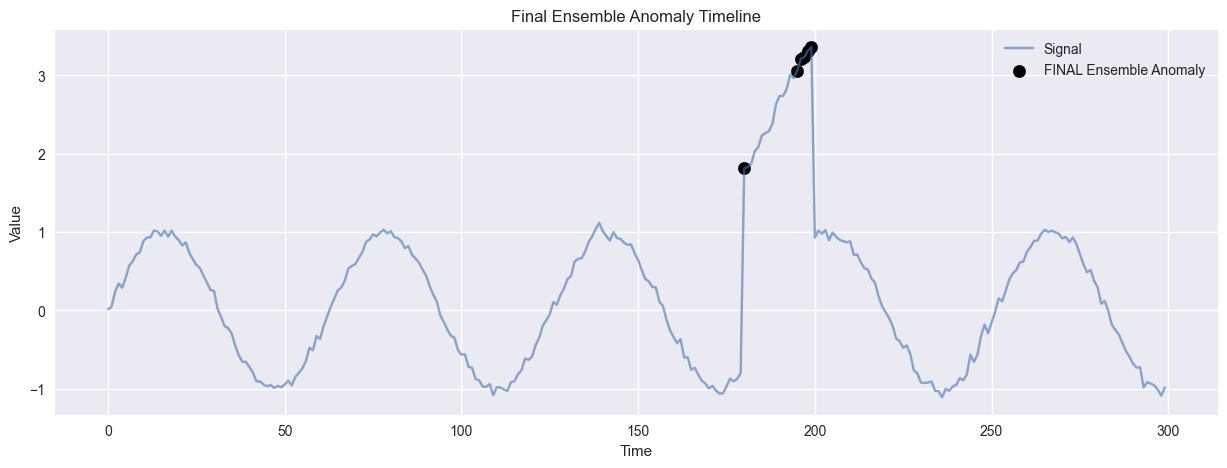

In [28]:
plt.figure(figsize=(15,5))
plt.plot(ts_df["time"], ts_df["value"], label="Signal", alpha=0.6)

plt.scatter(ts_df[ts_df["ensemble_anomaly"] == 1]["time"],
            ts_df[ts_df["ensemble_anomaly"] == 1]["value"],
            color="black", s=80, label="FINAL Ensemble Anomaly")

plt.title("Final Ensemble Anomaly Timeline")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()
